# Построение статистик 
Здесь представлены изображения и прилагаемый код к визуализациям подробным распределения выборок.

In [31]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [32]:
# df = pd.read_csv("/home/user/papkamusik/get_lucky/top100_removed_work/features.csv")
df = pd.read_csv("/home/user/papkamusik/AAAA/again/features.csv")
mf_df = pd.read_csv("/home/user/papkamusik/AAAA/again/hash_sex_age.csv")

merged_df = df.merge(
    mf_df,
    left_on="call_id",
    right_on="hash",
    how="left"   # чтобы не терять строки из df
)
df=merged_df[merged_df['role']=="user"]

# Построение распределений по длительности аудио и возрасту

/tmp/ipykernel_10331/4053647571.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = df.groupby(["duration_group", "sex"]).size().reset_index(name="count")


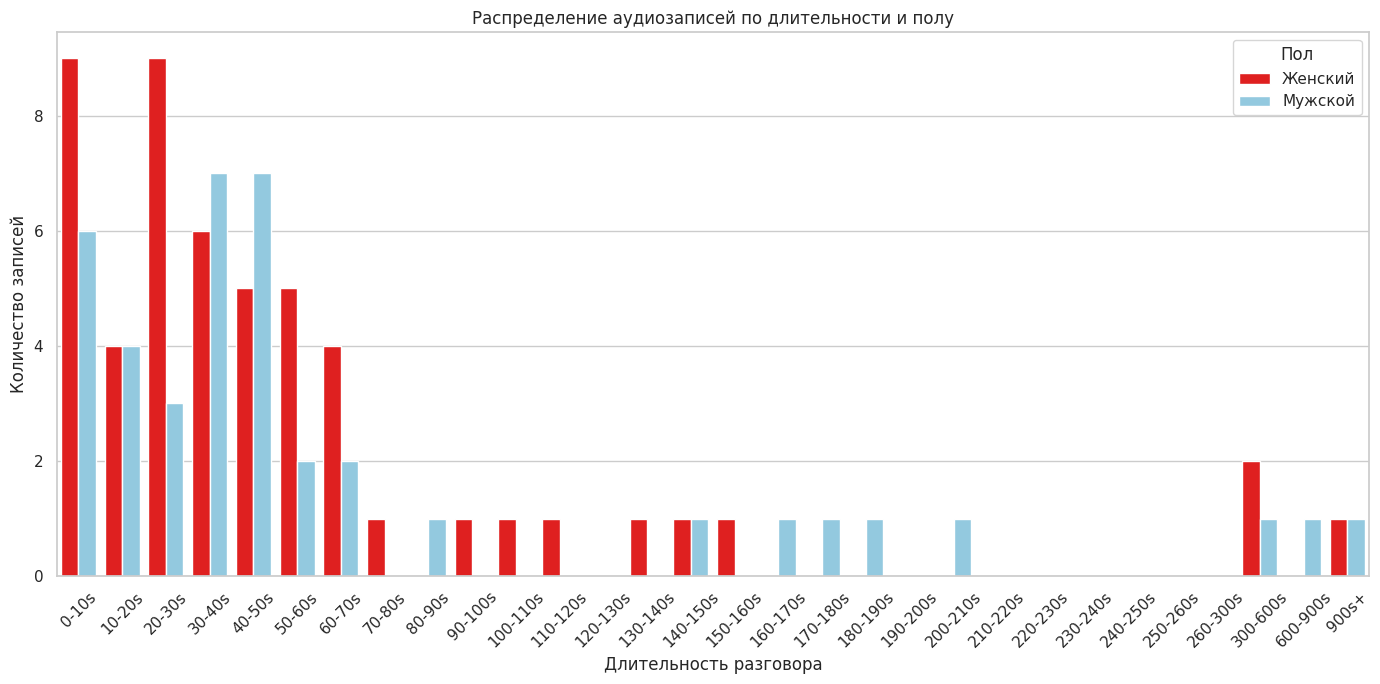

In [33]:
sns.set(style="whitegrid")
df = df.dropna()
df["sex"] = df["sex"].str.lower()


bins = [
    0, 10, 20, 30, 40, 50, 60, 70, 80, 90,
    100, 110, 120, 130, 140 ,150, 160, 170,
    180, 190, 200, 210,220,230,240, 250,260,
    300, 600, 900, float('inf')
]
labels = [
    "0-10s", "10-20s", "20-30s", "30-40s", "40-50s",
    "50-60s", "60-70s", "70-80s", "80-90s", "90-100s",
    "100-110s", "110-120s", "120-130s", "130-140s", "140-150s",
    "150-160s", "160-170s", "170-180s", "180-190s", "190-200s",
    "200-210s", "210-220s", "220-230s", "230-240s", "240-250s",
    "250-260s", "260-300s", "300-600s", "600-900s", "900s+"
]

# создаём duration_group НА ВСЁМ df
df["duration_group"] = pd.cut(df["total_duration"], bins=bins, labels=labels, right=False)

# считаем сразу с группировкой
counts = df.groupby(["duration_group", "sex"]).size().reset_index(name="count")


# строим график
plt.figure(figsize=(14, 7))

ax = sns.barplot(
    data=counts,
    x="duration_group",
    y="count",
    hue="sex",
    palette={"female": "red", "male": "skyblue"}
)


plt.title("Количество аудиозаписей по времени разговора по группам и полу")
plt.xlabel("Возрастная группа")
plt.ylabel("Количество записей")
plt.xticks(rotation=45)

plt.title("Распределение аудиозаписей по длительности и полу")
plt.xlabel("Длительность разговора")   # ✔ ИСПРАВЛЕНО
plt.ylabel("Количество записей")
plt.xticks(rotation=45)

# легенда
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ["Женский", "Мужской"], title="Пол")

plt.tight_layout()
plt.show()

/tmp/ipykernel_10331/1928220258.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = df.groupby(["age_group", "sex"]).size().reset_index(name="count")


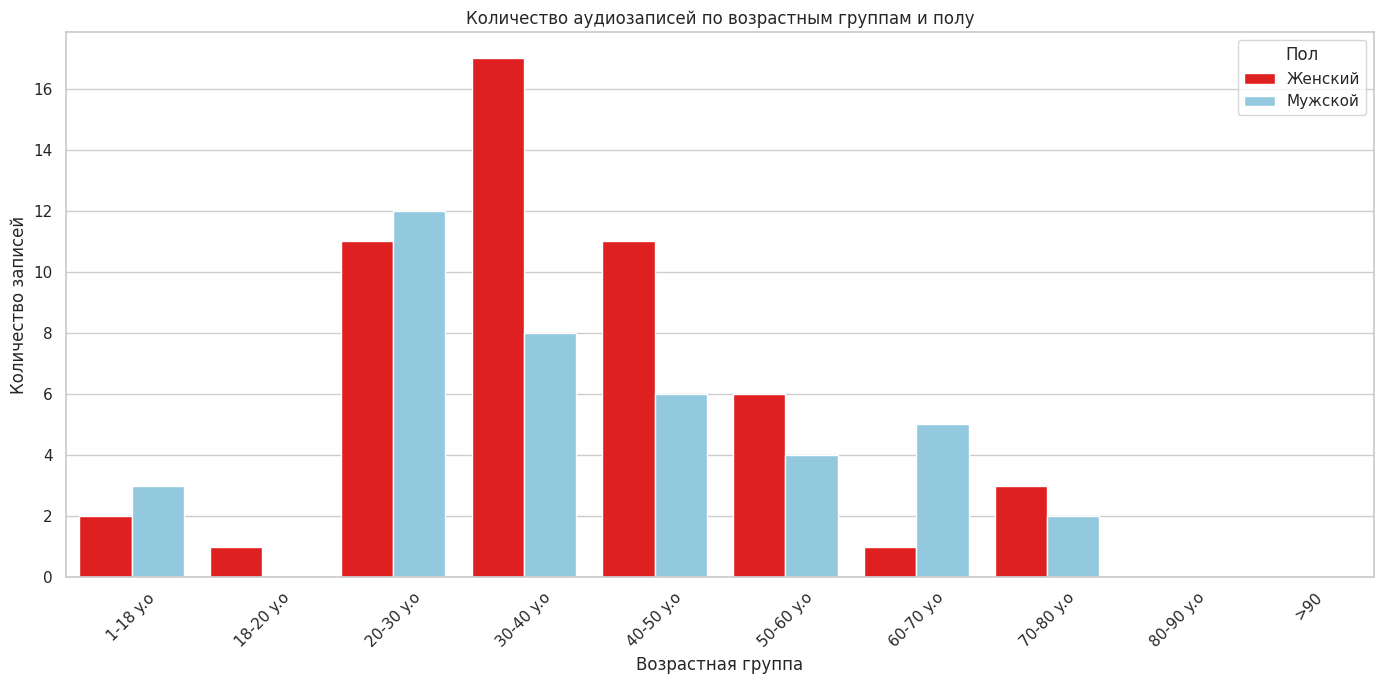

In [34]:
sns.set(style="whitegrid")

df = df.dropna()
df["sex"] = df["sex"].str.lower()

bins = [
    1, 18, 20, 30, 40, 50, 60, 70, 80, 90, float('inf')
]
labels = [      
    "1-18 y.o", "18-20 y.o", "20-30 y.o", "30-40 y.o", "40-50 y.o",
    "50-60 y.o", "60-70 y.o", "70-80 y.o", "80-90 y.o", ">90"
]

# создаём age_group НА ВСЁМ df
df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels, right=False)

# считаем сразу с группировкой
counts = df.groupby(["age_group", "sex"]).size().reset_index(name="count")

# строим график
plt.figure(figsize=(14, 7))

ax = sns.barplot(
    data=counts,
    x="age_group",
    y="count",
    hue="sex",
    palette={"female": "red", "male": "skyblue"}
)

plt.title("Количество аудиозаписей по возрастным группам и полу")
plt.xlabel("Возрастная группа")
plt.ylabel("Количество записей")
plt.xticks(rotation=45)


# меняем название легенды и подписи
handles, labels = ax.get_legend_handles_labels()

ax.legend(handles, ["Женский", "Мужской"], title="Пол")

plt.tight_layout()
plt.show()

# Удаление не релевантных пациентов в выборке


In [ ]:
print(f'До удаления не подходящих аудио: {len(df)}')

# Удаление возрастных групп младше 18 лет и старше 80 лет
df = df[df["age_group"] != "1-18 y.o"]
df = df[df["age_group"] != "80-90 y.o"]
df = df[df["age_group"] != ">90"]

# Удаление аудио меньше 20 секунд
df = df[df["duration_group"] != "0-10s"]
df = df[df["duration_group"] != "10-20s"]

# Cовпадение имеющегося гендера и предсказанного моделью
df = df[df['sex']==df["defined_gender"]]

print(f'После удаления не подходящих аудио: {len(df)}')

До удаления не подходящих аудио: 92
После удаления не подходящих аудио: 54


# Таблица корреляций
Построение корреляции для выявления наиболее скоррелированных признаков (0.7). В случае обнаружения таких признаков удаления их с обязательным указанием ниже.

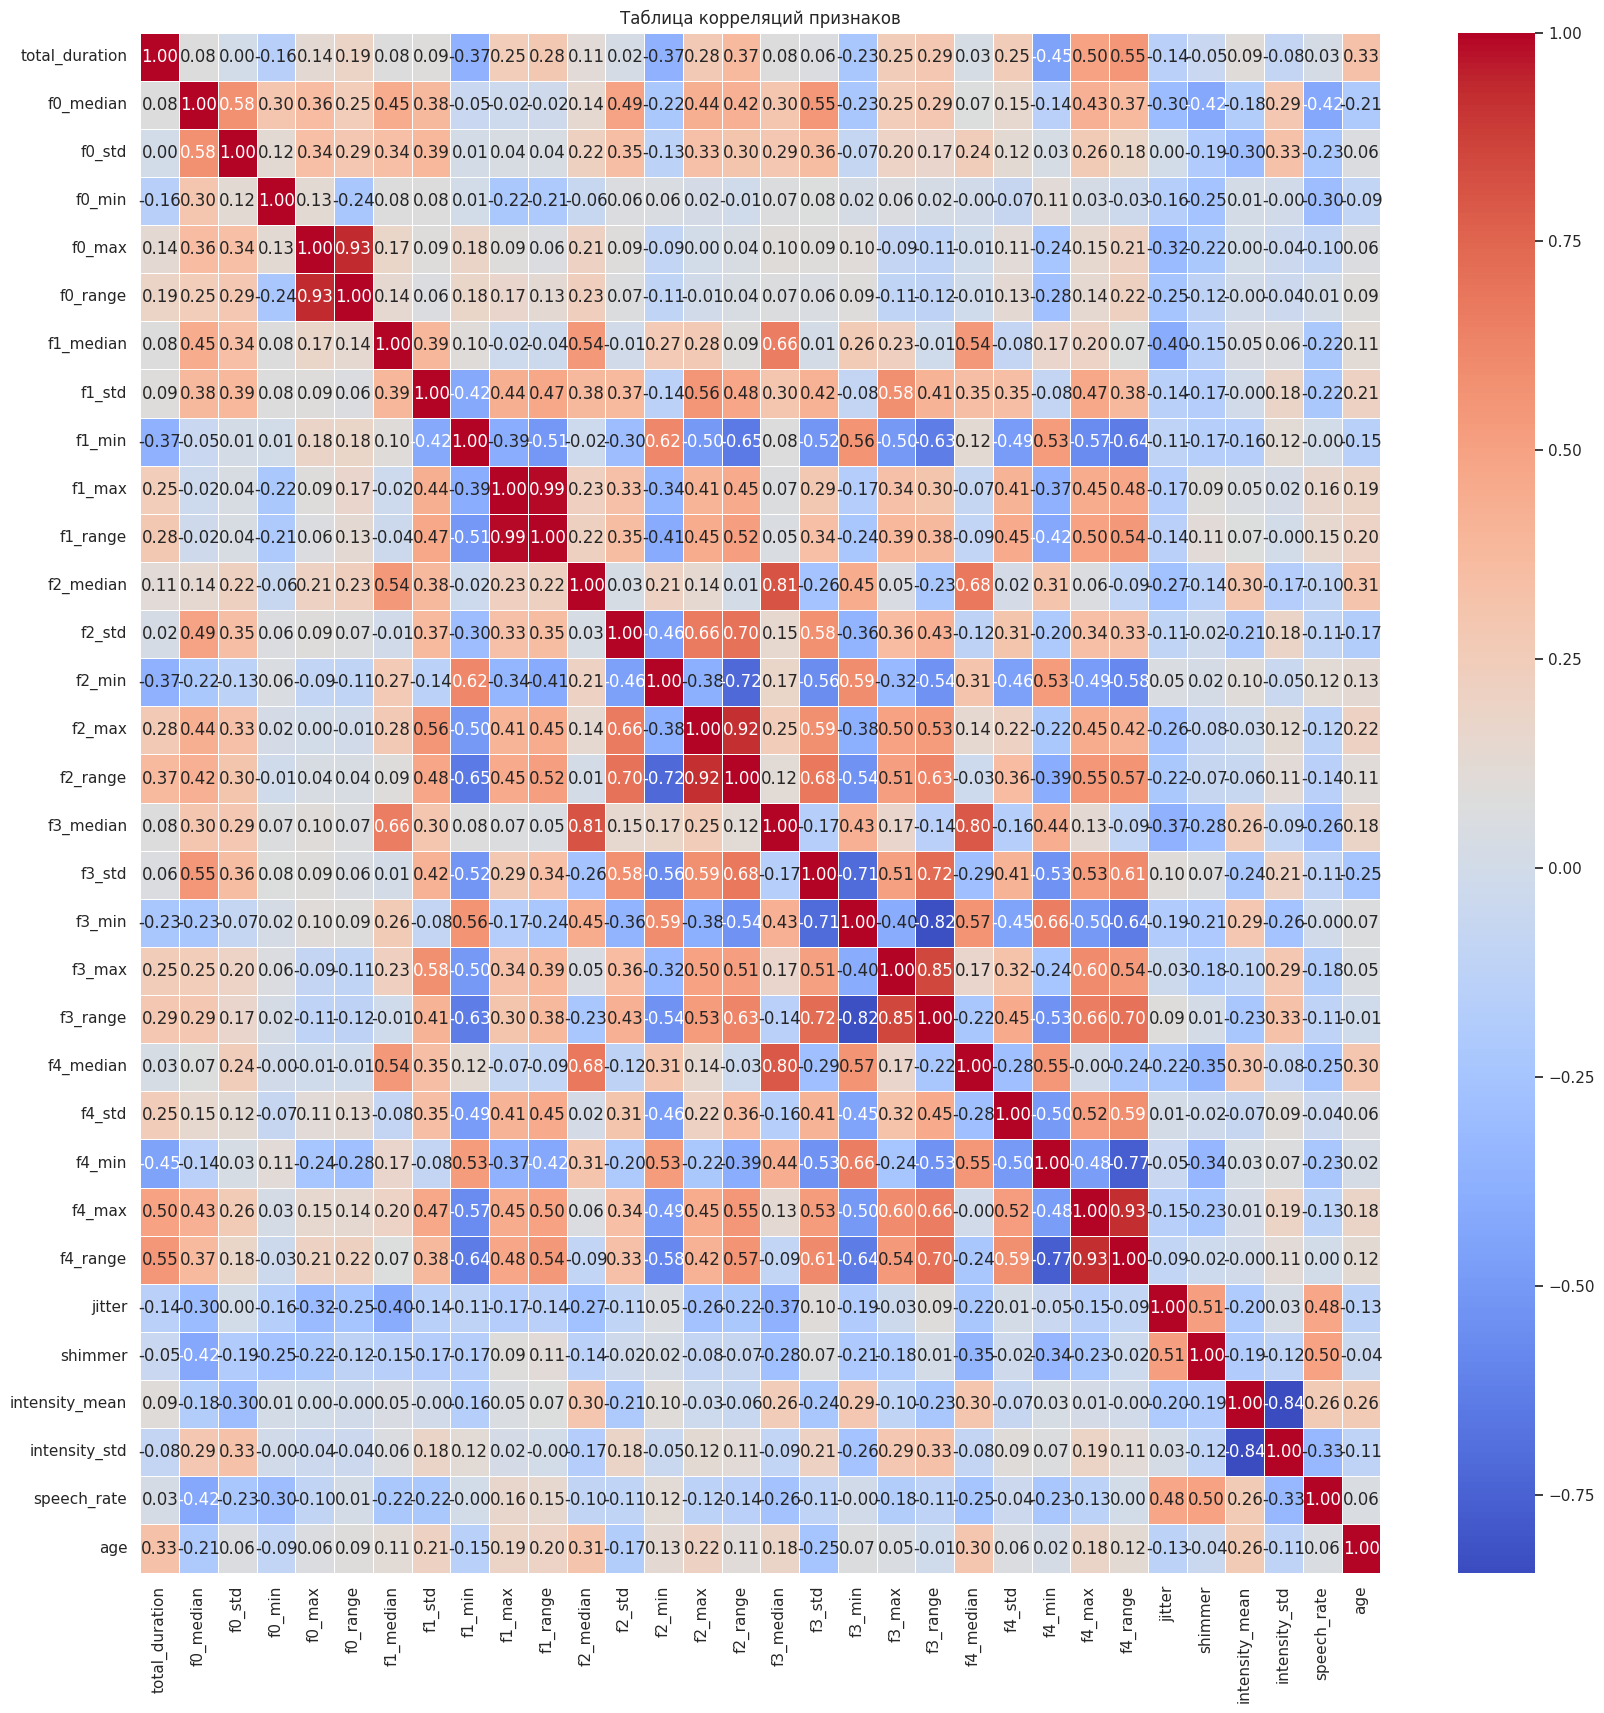


f0_max
  f0_range: 0.93

f0_range
  f0_max: 0.93

f1_max
  f1_range: 0.99

f1_range
  f1_max: 0.99

f2_median
  f3_median: 0.81

f2_std
  f2_range: 0.70

f2_min
  f2_range: -0.72

f2_max
  f2_range: 0.92

f2_range
  f2_std: 0.70
  f2_min: -0.72
  f2_max: 0.92

f3_median
  f2_median: 0.81
  f4_median: 0.80

f3_std
  f3_min: -0.71
  f3_range: 0.72

f3_min
  f3_std: -0.71
  f3_range: -0.82

f3_max
  f3_range: 0.85

f3_range
  f3_std: 0.72
  f3_min: -0.82
  f3_max: 0.85
  f4_range: 0.70

f4_median
  f3_median: 0.80

f4_min
  f4_range: -0.77

f4_max
  f4_range: 0.93

f4_range
  f3_range: 0.70
  f4_min: -0.77
  f4_max: 0.93

intensity_mean
  intensity_std: -0.84

intensity_std
  intensity_mean: -0.84


In [36]:
df_numeric = df.select_dtypes(include=['number'])
corr = df_numeric.corr()

plt.figure(figsize=(20, 20))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    xticklabels=df_numeric.columns,
    yticklabels=df_numeric.columns
)
plt.title('Таблица корреляций признаков')
plt.show()

# Потом переделать!!!
for column in corr.columns:
    high_corr = corr[column][abs(corr[column]) > 0.7]

    # убираем корреляцию признака с самим собой (=1)
    high_corr = high_corr[high_corr.index != column]

    if len(high_corr) > 0:
        print(f"\n{column}")

        for idx, value in high_corr.items():
            print(f"  {idx}: {value:.2f}")

# Удаляем скоррелированные столбцы

In [37]:
df_numeric.drop(columns=["f0_min","f0_max","f0_range",
                         "f1_min","f1_max","f1_range",
                         "f2_min","f2_max","f2_range",
                         "f3_min","f3_max","f3_range","f3_median", "f3_std",
                         "f4_min","f4_max","f4_range","f4_median", "f4_std",
                         "intensity_std"], inplace=True)
df.drop(columns=["f0_min","f0_max","f0_range",
                         "f1_min","f1_max","f1_range",
                         "f2_min","f2_max","f2_range",
                         "f3_min","f3_max","f3_range","f3_median", "f3_std",
                         "f4_min","f4_max","f4_range","f4_median", "f4_std",
                         "intensity_std"], inplace=True)

# Еще раз строим таблицу корреляций

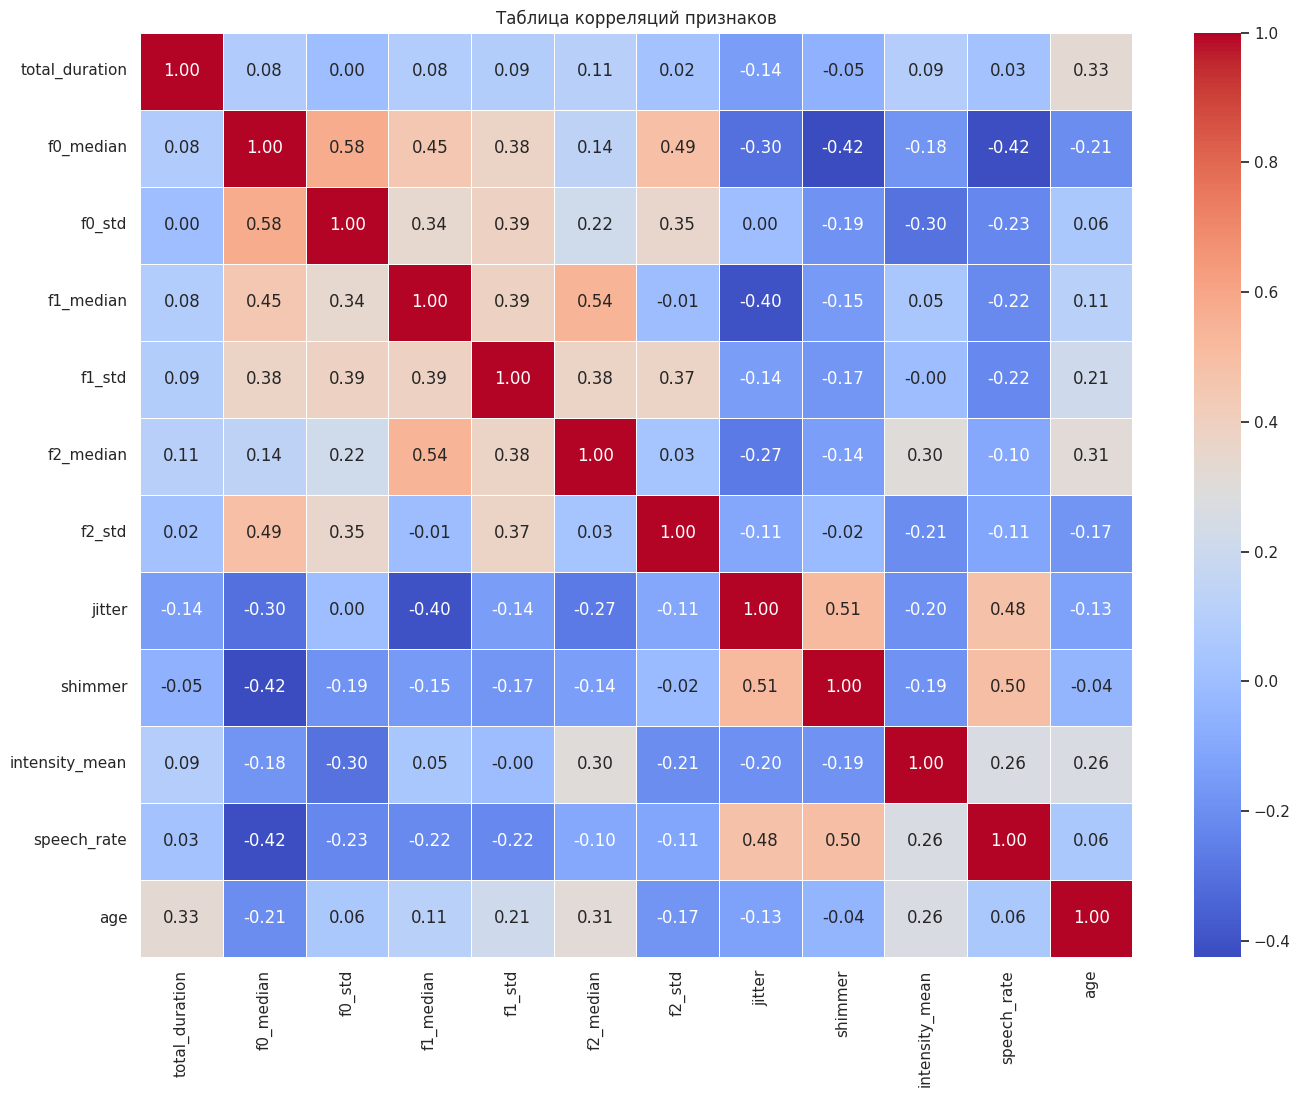

In [38]:
corr = df_numeric.corr()

# russian_labels = [УКАЖИТЕ_ПО_ПОРЯДКУ]

plt.figure(figsize=(16, 12))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    xticklabels=df_numeric.columns,
    yticklabels=df_numeric.columns
)
plt.title('Таблица корреляций признаков')
plt.show()

Хочу в GWAS использовать 
- f0_median - groundtruth
- f1_median - F1 связан с открытостью гласных положением языка (высоко/низко)
- f2_median - F2 связан с  передне/заднеязычными позициями артикуляцией гласных
- jitter - измеряет нестабильность вибрации голосовых связок(высокое значение дрожание)
- shimmer - нестабильные изменения в голосе человека
- speech_rate - отражает когнитивную скорость обработки, уверенность речи

# Строим распределение через PairGrid

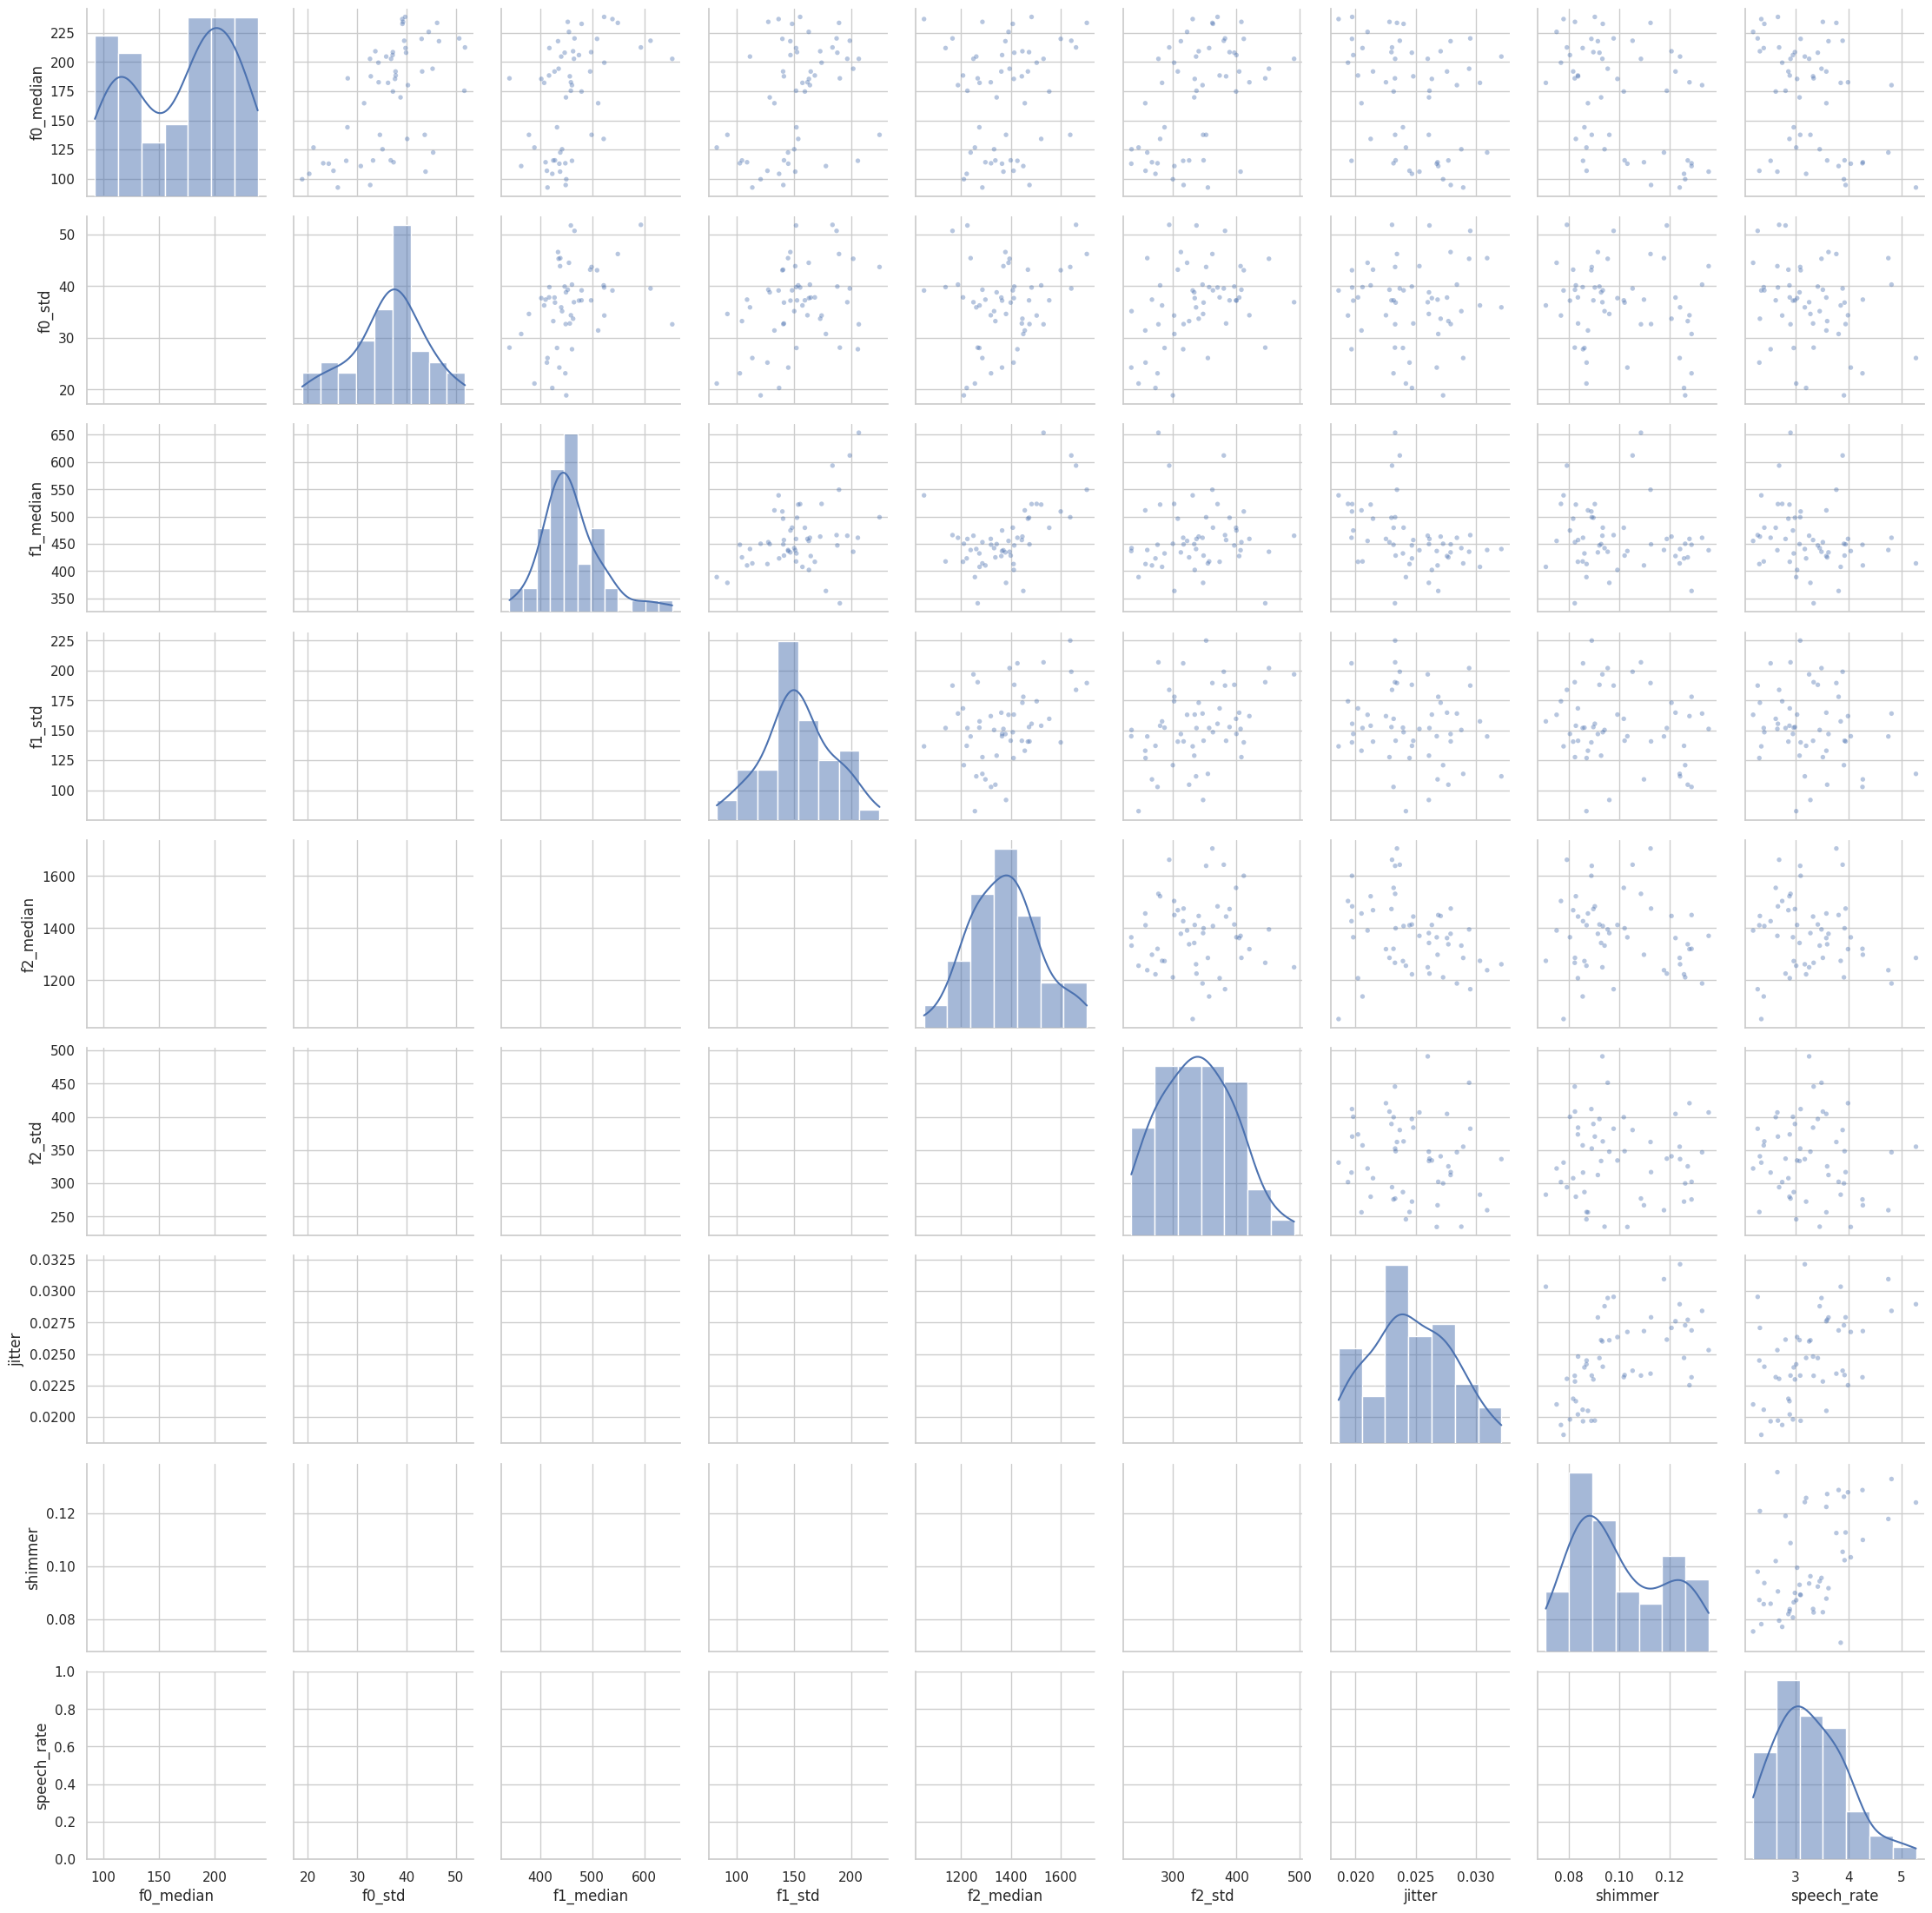

In [23]:
df_pair = df_numeric.drop(columns=["total_duration","age", "intensity_mean"])

# Создаём сетку
g = sns.PairGrid(df_pair, diag_sharey=False)

# Верхний треугольник — пустой
# g.map_lower(plt.scatter, alpha=0)   # или g.map_upper(lambda *args, **kwargs: None)

# Диагональ — гистограммы или kde
g.map_diag(sns.histplot, kde=True)

# Нижний треугольник — scatter plot с настройками
g.map_upper(sns.scatterplot, alpha=0.4, s=15, edgecolor='none')


plt.show()

# Построение распределения f0-median для проверки достоверности выборки



In [27]:
import plotly.express as px
import pandas as pd
import numpy as np

numeric = df.select_dtypes(include=[np.number]).dropna(axis=1, how='all')

# просто копируем исходные данные
X_scaled = numeric.copy()

# добавляем служебные колонки
X_scaled["defined_gender"] = df["defined_gender"].values
X_scaled["call_id"] = df["call_id"].values

fig = px.scatter(
    X_scaled,
    x="f0_median",
    y="f0_std",
    color="defined_gender",
    hover_data=["call_id"]
)

fig.show()

# Построение статистик по возрастным группам

In [39]:
def box_draw(df, metric="f0_median"):
    sns.set(style="whitegrid")

    # Усреднение по группам (для линии тренда)
    trend = df.groupby(["age_group", "sex"])[metric].mean().reset_index()

    plt.figure(figsize=(14, 7))

    # Boxplot
    sns.boxplot(
        data=df,
        x="age_group",
        y=metric,
        hue="sex",
        palette={"female": "red", "male": "skyblue"}
    )

    # Линия тренда
    for gender, color in [("female", "red"), ("male", "skyblue")]:
        temp = trend[trend["sex"] == gender].sort_values("age_group")

        plt.plot(
            temp["age_group"],
            temp[metric],
            linewidth=2,
            color=color,
            marker="o",
            label=f"{gender} trend"
        )

    plt.title(f"Boxplot + линия тренда для {metric}")
    plt.xlabel("Возрастная группа")
    plt.ylabel("Значение метрики")
    plt.xticks(rotation=45)

    plt.legend(title="Gender")
    plt.tight_layout()
    plt.show()  

/tmp/ipykernel_10331/3885740684.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trend = df.groupby(["age_group", "sex"])[metric].mean().reset_index()


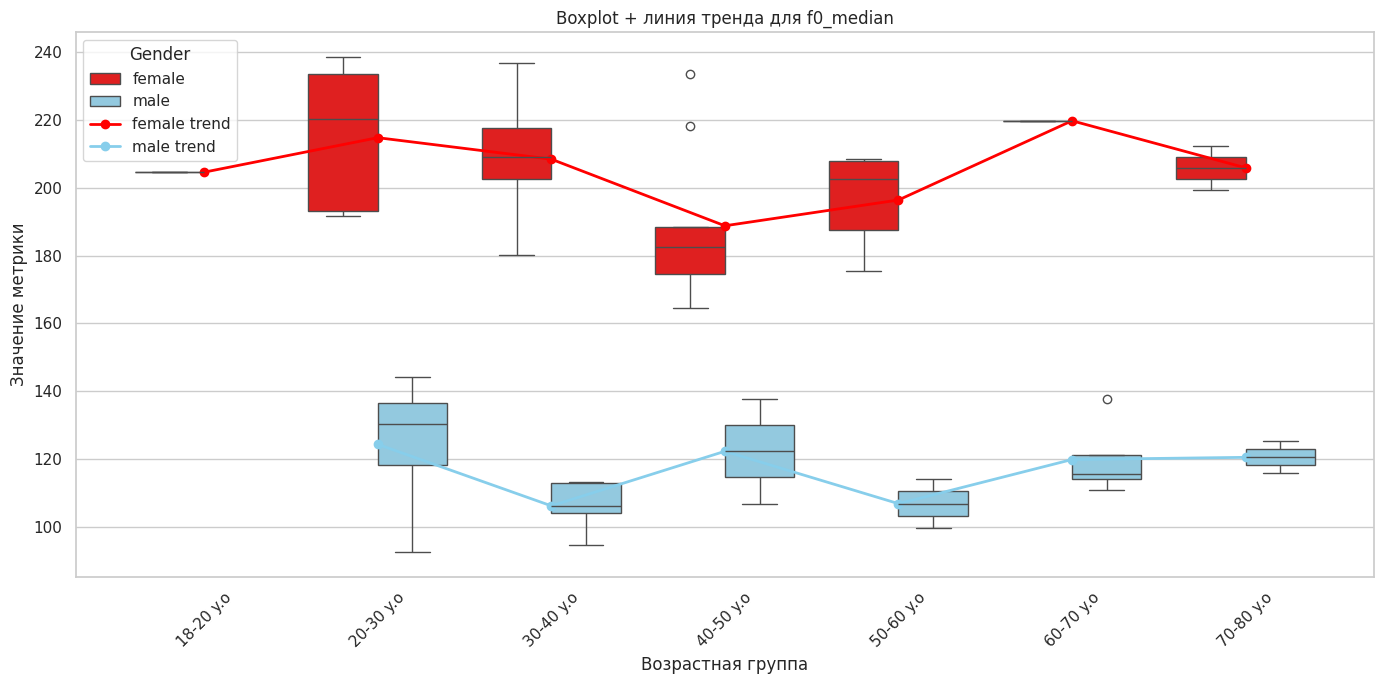

/tmp/ipykernel_10331/3885740684.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trend = df.groupby(["age_group", "sex"])[metric].mean().reset_index()


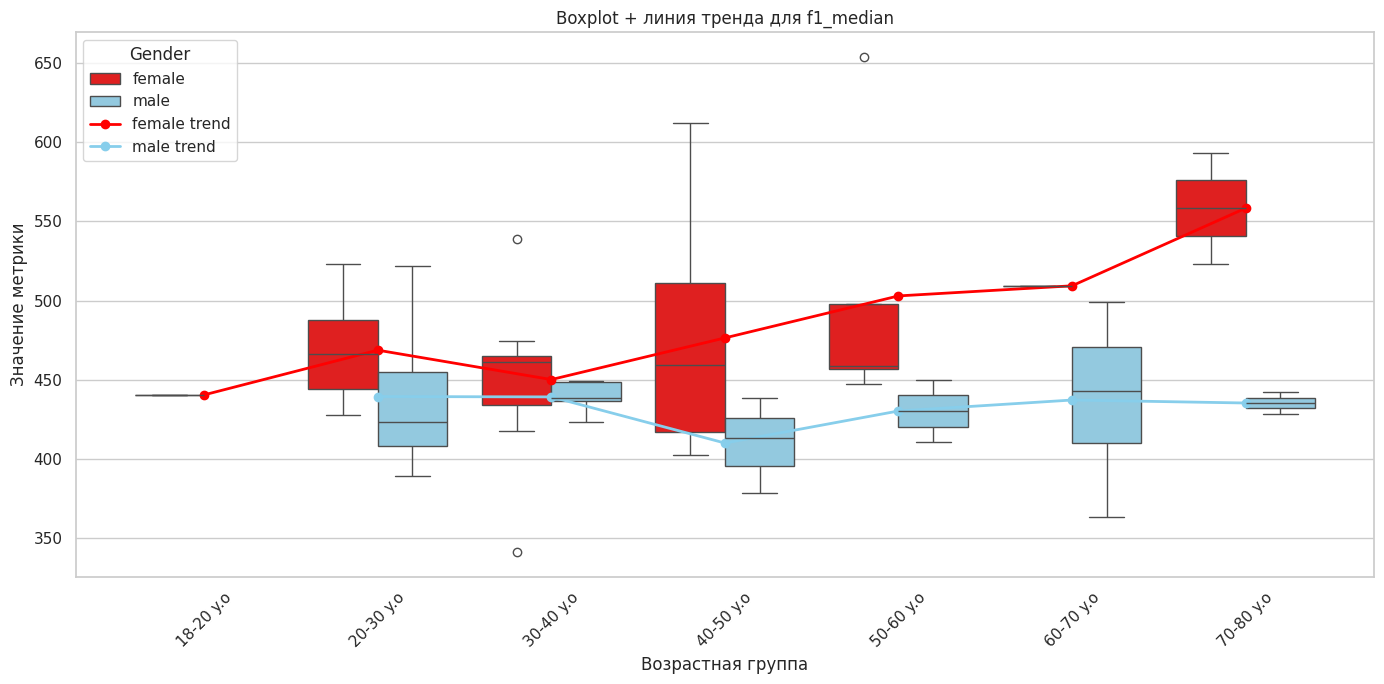

/tmp/ipykernel_10331/3885740684.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trend = df.groupby(["age_group", "sex"])[metric].mean().reset_index()


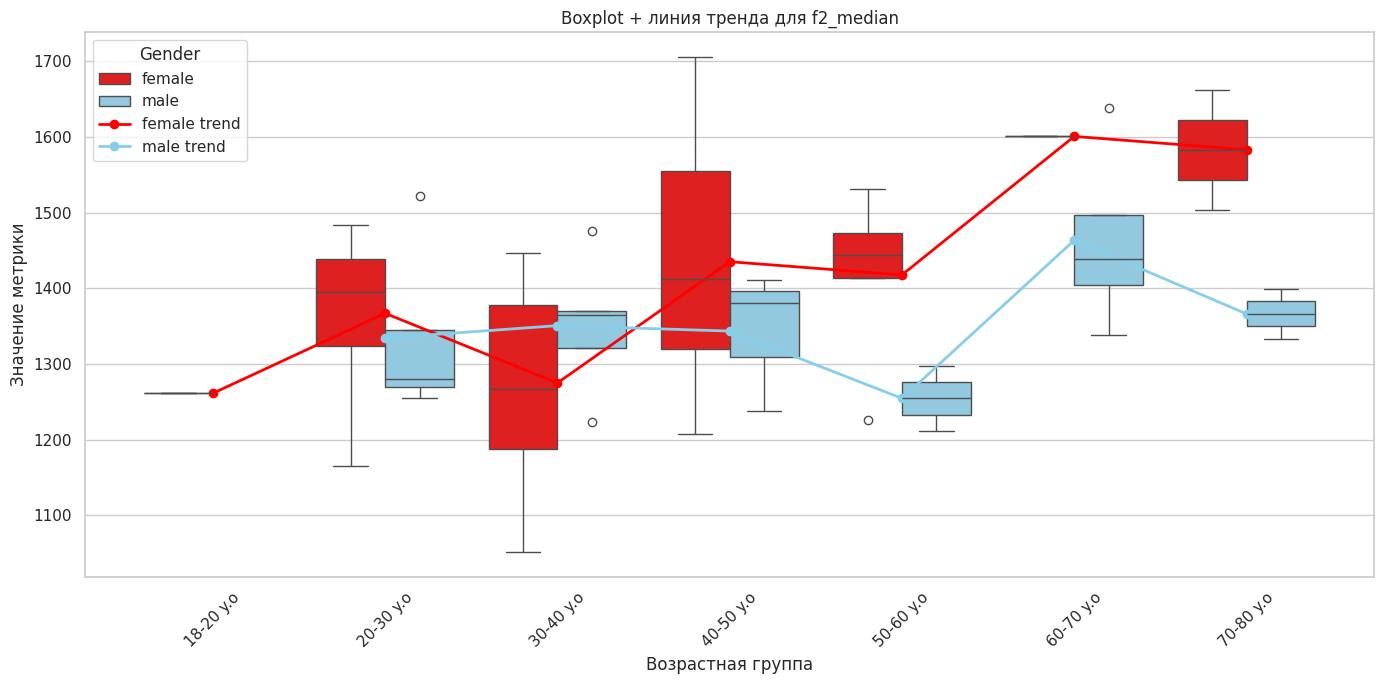

In [40]:
# box_draw(df, metric="your_metric_name")
box_draw(df, metric="f0_median")
box_draw(df, metric="f1_median")
box_draw(df, metric="f2_median")

In [ ]:
df.drop(columns=["hash", "sex" ,"role", "duration_group", "age_group"], inplace=True)
df.rename(columns={"defined_gender": "gender"}, inplace=True)

In [45]:
df.to_csv("/home/user/papkamusik/AAAA/again/filtered_geno.csv", index=False)